In [51]:
import warnings
warnings.filterwarnings('ignore')

import os
import io
import requests
from math import sqrt
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose,STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet
import pmdarima as pm

In [6]:
df = pd.read_csv("india_monthly_full_release_long_format.csv")
df.head()

,Country,Country code,State,State code,State type,Date,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
0,India,IND,Andaman and Nicobar,AN,Union territory,2019-01-01,Capacity,Aggregate fuel,Clean,MW,NaN,NaN,NaN
1,India,IND,Andaman and Nicobar,AN,Union territory,2019-01-01,Capacity,Aggregate fuel,Fossil,MW,NaN,NaN,NaN
2,India,IND,Andaman and Nicobar,AN,Union territory,2019-01-01,Capacity,Aggregate fuel,Gas and Other Fossil,MW,NaN,NaN,NaN
3,India,IND,Andaman and Nicobar,AN,Union territory,2019-01-01,Capacity,Aggregate fuel,"Hydro, Bioenergy and Other Renewables",MW,NaN,NaN,NaN
4,India,IND,Andaman and Nicobar,AN,Union territory,2019-01-01,Capacity,Aggregate fuel,Renewables,MW,NaN,NaN,NaN


In [7]:
df.State.value_counts()

State
Andaman and Nicobar                         6162
Andhra Pradesh                              6162
Maharashtra                                 6162
Manipur                                     6162
Meghalaya                                   6162
Mizoram                                     6162
Nagaland                                    6162
Odisha                                      6162
Puducherry                                  6162
Punjab                                      6162
Rajasthan                                   6162
Sikkim                                      6162
Tamil Nadu                                  6162
Telangana                                   6162
Tripura                                     6162
Uttar Pradesh                               6162
Uttarakhand                                 6162
Madhya Pradesh                              6162
West Bengal                                 6162
Gujarat                                     6162
Bihar         

In [12]:
df_t = df[df["State"] == "Tamil Nadu"]
df_t = df_t[df_t["Subcategory"] == "Total"]
df_t = df_t[df_t["Unit"] == "GWh"]
df_t.head(20)

,Country,Country code,State,State code,State type,Date,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
189969,India,IND,Tamil Nadu,TN,state,2019-01-01,Electricity generation,Total,Total Generation,GWh,7643.41,NaN,NaN
190047,India,IND,Tamil Nadu,TN,state,2019-02-01,Electricity generation,Total,Total Generation,GWh,7487.43,NaN,NaN
190125,India,IND,Tamil Nadu,TN,state,2019-03-01,Electricity generation,Total,Total Generation,GWh,8129.01,NaN,NaN
190203,India,IND,Tamil Nadu,TN,state,2019-04-01,Electricity generation,Total,Total Generation,GWh,7862.02,NaN,NaN
190281,India,IND,Tamil Nadu,TN,state,2019-05-01,Electricity generation,Total,Total Generation,GWh,9135.89,NaN,NaN
190359,India,IND,Tamil Nadu,TN,state,2019-06-01,Electricity generation,Total,Total Generation,GWh,9956.03,NaN,NaN
190437,India,IND,Tamil Nadu,TN,state,2019-07-01,Electricity generation,Total,Total Generation,GWh,9688.40,NaN,NaN
190515,India,IND,Tamil Nadu,TN,state,2019-08-01,Electricity generation,Total,Total Generation,GWh,9455.15,NaN,NaN
190593,India,IND,Tamil Nadu,TN,state,2019-09-01,Electricity generation,Total,Total Generation,GWh,8759.00,NaN,NaN
190671,India,IND,Tamil Nadu,TN,state,2019-10-01,Electricity generation,Total,Total Generation,GWh,7913.85,NaN,NaN


In [13]:
df_t.shape

(79, 13)

In [14]:
df_final = df_t[["Date","Value"]].copy()

In [15]:
df_final

,Date,Value
189969,2019-01-01,7643.41
190047,2019-02-01,7487.43
190125,2019-03-01,8129.01
190203,2019-04-01,7862.02
190281,2019-05-01,9135.89
...,...,...
195741,2025-03-01,10491.04
195819,2025-04-01,9753.51
195897,2025-05-01,10921.98
195975,2025-06-01,13519.46


In [17]:
df_final["Date"] = pd.to_datetime(df["Date"])
df_final = df_final.set_index("Date").sort_index()

In [18]:
df_final

,Value
Date,
2019-01-01,7643.41
2019-02-01,7487.43
2019-03-01,8129.01
2019-04-01,7862.02
2019-05-01,9135.89
...,...
2025-03-01,10491.04
2025-04-01,9753.51
2025-05-01,10921.98


<Figure size 1200x400 with 0 Axes>

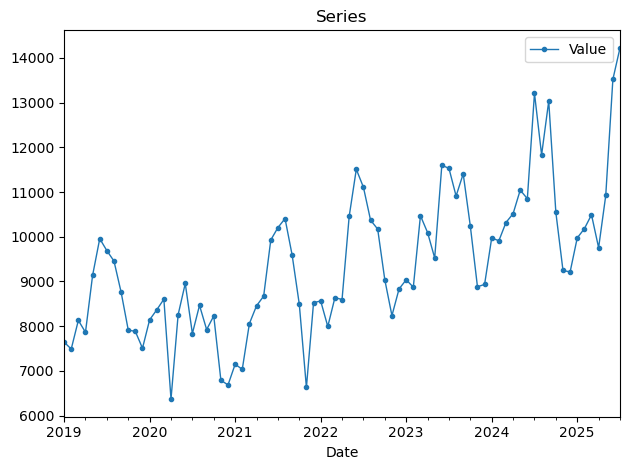

In [19]:
plot_series(df_final)

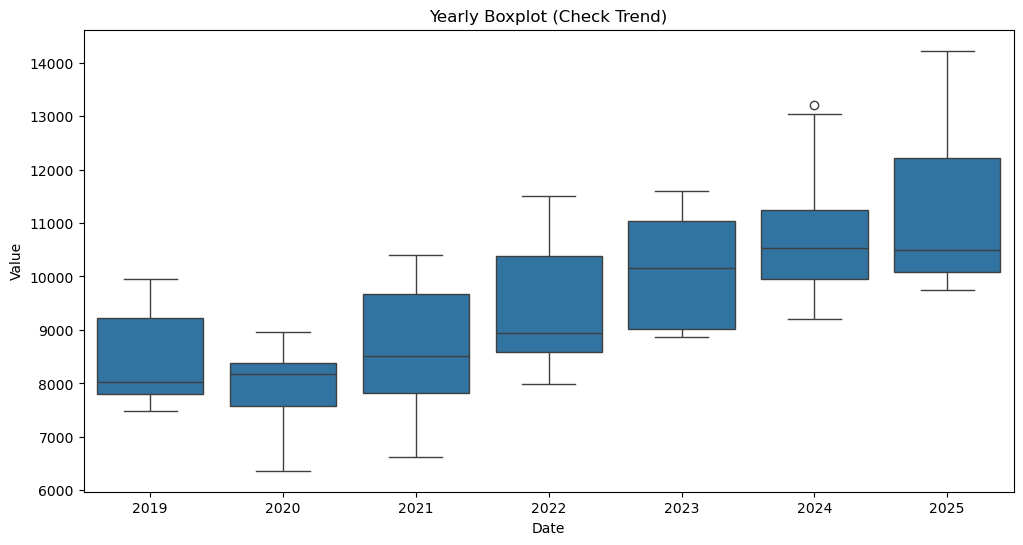

In [20]:
plt.figure(figsize=(12,6))
sns.boxplot(x=df_final.index.year, y="Value", data=df_final)
plt.title("Yearly Boxplot (Check Trend)")
plt.show()

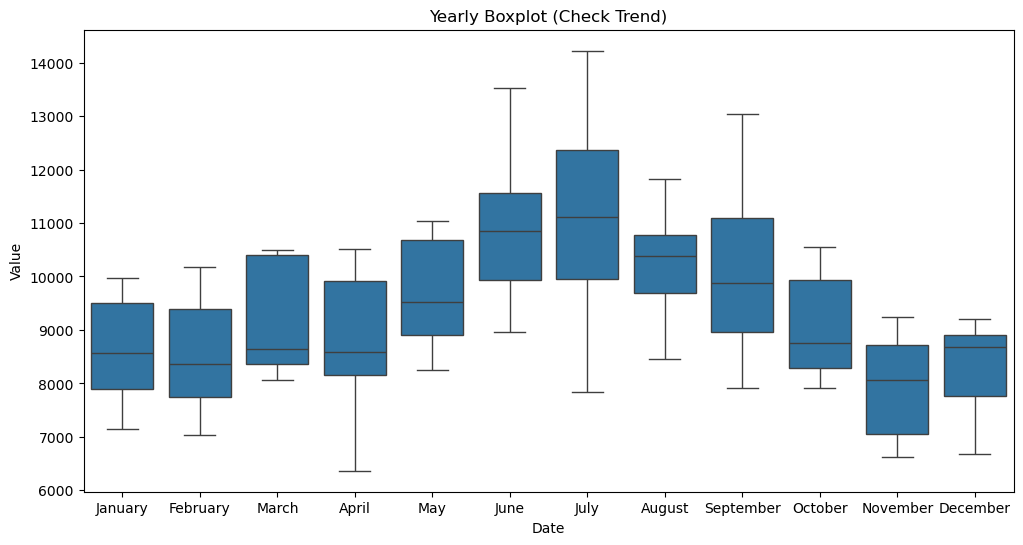

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(x=df_final.index.month_name(), y="Value", data=df_final)
plt.title("Yearly Boxplot (Check Trend)")
plt.show()

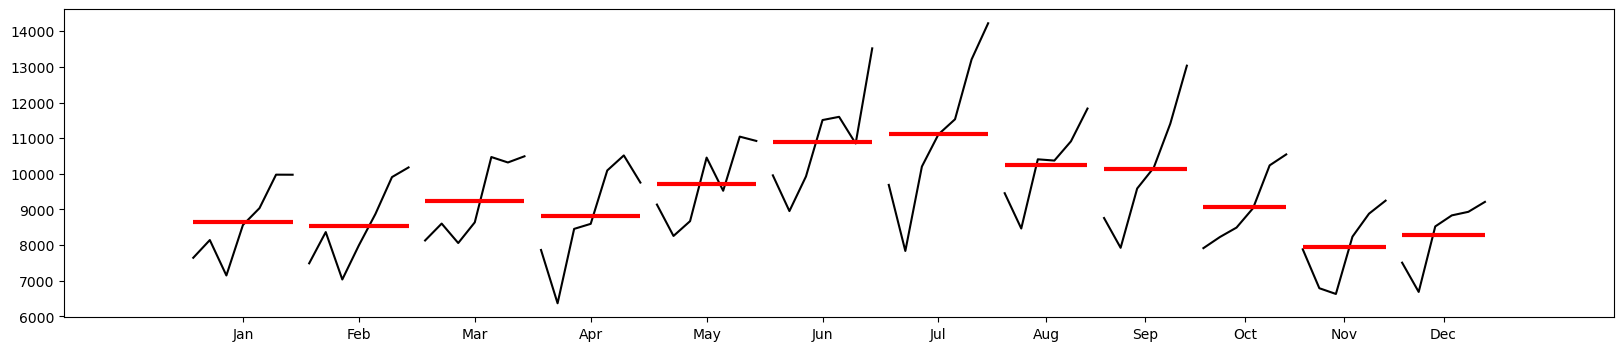

In [25]:
fig, ax = plt.subplots(1,1,figsize=(20,4))
sm.graphics.tsa.month_plot(df_final, ax=ax)
plt.show()

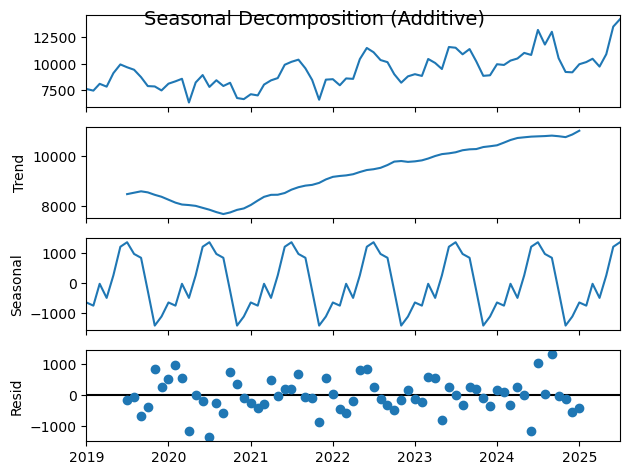

In [27]:
result = seasonal_decompose(df_final, model='additive', period=12)
result.plot().suptitle("Seasonal Decomposition (Additive)", fontsize=14)
plt.show()

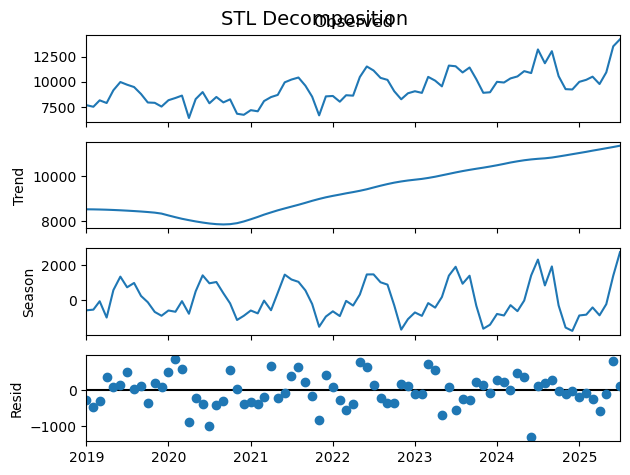

In [30]:
stl = STL(df_final, period=12).fit()
stl.plot()
plt.suptitle("STL Decomposition", fontsize=14)
plt.show()

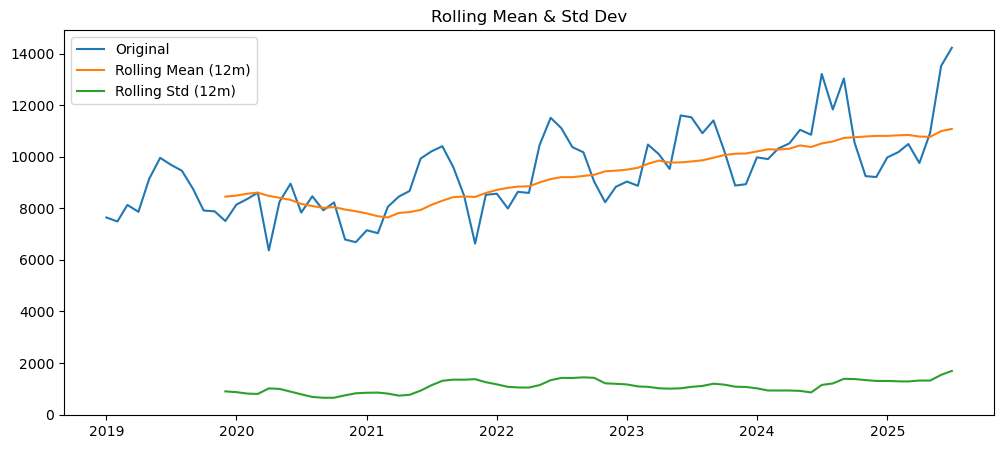

In [31]:
roll_mean = df_final.rolling(window=12).mean()
roll_std = df_final.rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df_final, label="Original")
plt.plot(roll_mean, label="Rolling Mean (12m)")
plt.plot(roll_std, label="Rolling Std (12m)")
plt.legend()
plt.title("Rolling Mean & Std Dev")
plt.show()

In [32]:
adf_test(df_final, "Raw Series")
adf_test(df_final.diff(), "1st Difference")
adf_test(df_final.diff(12), "Seasonal Difference (12)")

ADF test for Raw Series:
  ADF Statistic: 0.7356, p-value: 0.9905
    Critical Value (1%): -3.5320
    Critical Value (5%): -2.9058
    Critical Value (10%): -2.5904

ADF test for 1st Difference:
  ADF Statistic: -6.3745, p-value: 0.0000
    Critical Value (1%): -3.5320
    Critical Value (5%): -2.9058
    Critical Value (10%): -2.5904

ADF test for Seasonal Difference (12):
  ADF Statistic: -4.0984, p-value: 0.0010
    Critical Value (1%): -3.5553
    Critical Value (5%): -2.9157
    Critical Value (10%): -2.5957



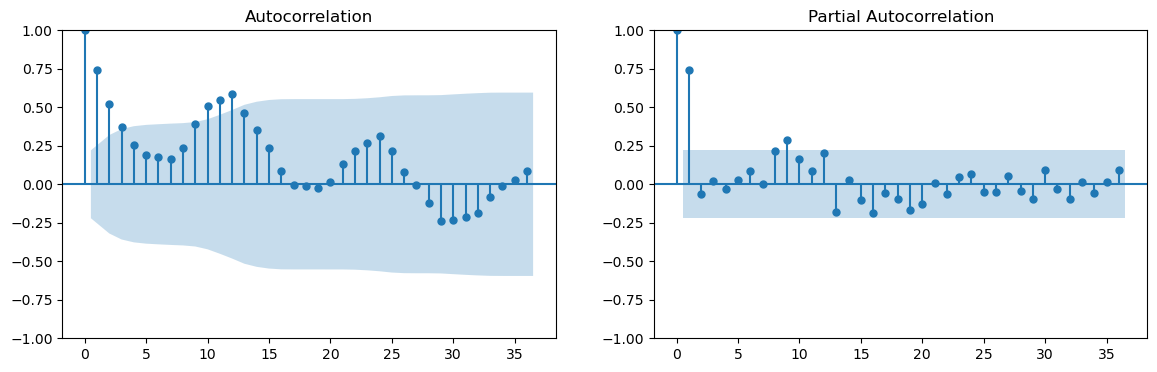

In [34]:
fig, axes = plt.subplots(1,2,figsize=(14,4))
plot_acf(df_final.dropna(), lags=36, ax=axes[0])
plot_pacf(df_final.dropna(), lags=36, ax=axes[1])
plt.show()

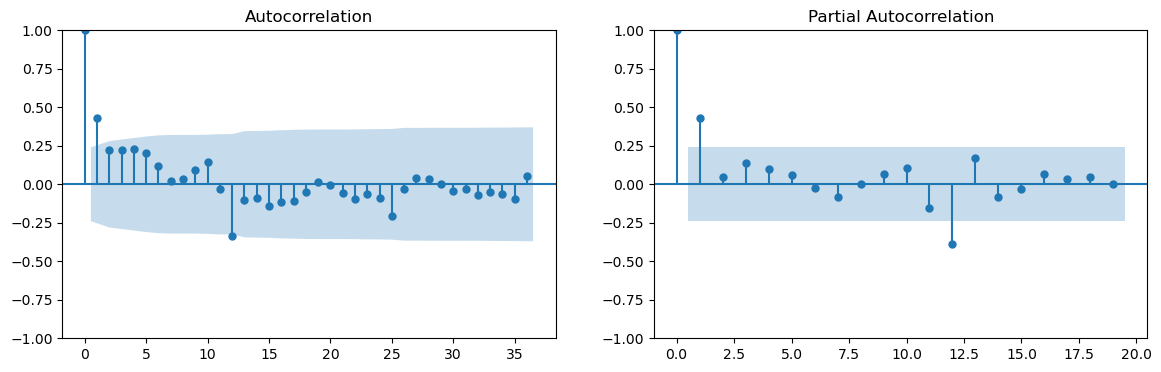

In [36]:
fig, axes = plt.subplots(1,2,figsize=(14,4))
plot_acf(df_final.diff(12).dropna(), lags=36, ax=axes[0])
plot_pacf(df_final.diff(12).dropna(), ax=axes[1])
plt.show()

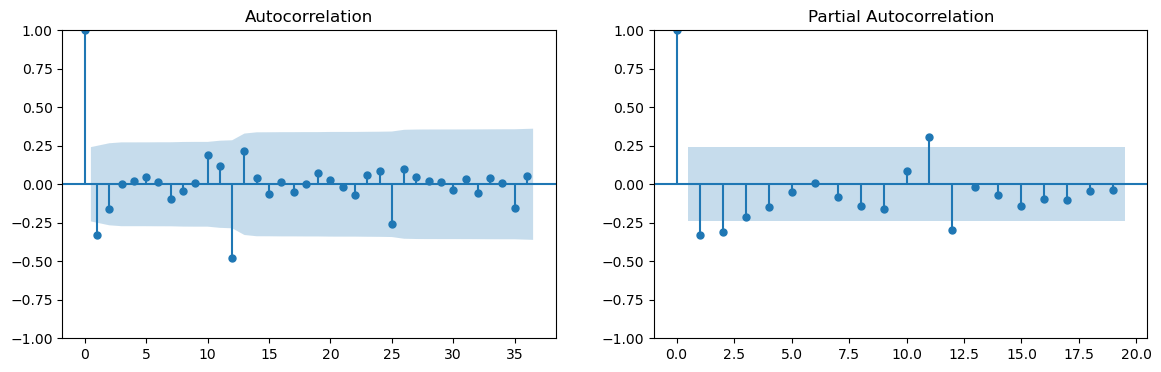

In [37]:
fig, axes = plt.subplots(1,2,figsize=(14,4))
plot_acf(df_final.diff(12).dropna().diff().dropna(), lags=36, ax=axes[0])
plot_pacf(df_final.diff(12).dropna().diff().dropna(), ax=axes[1])
plt.show()

In [48]:
def train_test_split_series(series, test_periods=12, freq=None):
    """
    Splits series into train & test by last `test_periods` observations.
    If freq is provided (e.g., 'M','D'), ensures regular index by resampling / reindexing.
    """
    s = series.copy().dropna()
    if freq is not None:
        s = s.asfreq(freq)  # will insert NaNs if irregular
        s = s.fillna(method='ffill')
    train = s.iloc[:-test_periods]
    test = s.iloc[-test_periods:]
    return train, test

def evaluate_forecast(y_true, y_pred):
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {'rmse': rmse, 'mae': mae}

def plot_forecasts(train, test, forecasts_dict, title="Forecast comparison"):
    plt.figure(figsize=(12,5))
    train.plot(label='train', color='C0')
    test.plot(label='test', color='C1')
    for name, pred in forecasts_dict.items():
        try:
            pred.plot(label=name)
        except Exception:
            plt.plot(pred.index, pred.values, label=name)
    plt.legend()
    plt.title(title)
    plt.show()


# ------------------------
# 1) Triple Exponential Smoothing (Holt-Winters) + grid search
# ------------------------
def hw_grid_search(train, test, seasonal_periods, 
                   alphas=[None, 0.2, 0.4], betas=[None, 0.05], gammas=[None, 0.05],
                   trends=[ 'add', None ], seasonals=['add', 'mul']):
    """
    Modest grid-search for Holt-Winters.
    If alpha is None -> let statsmodels optimize that param (optimized=True).
    Returns best_fit, results_df
    """
    results = []
    best = None
    for trend in trends:
        for seasonal in seasonals:
            for a in alphas:
                for b in betas:
                    for g in gammas:
                        try:
                            model = ExponentialSmoothing(train,
                                                         trend=trend,
                                                         seasonal=seasonal,
                                                         seasonal_periods=seasonal_periods)
                            fit = model.fit(smoothing_level=a, smoothing_slope=b, smoothing_seasonal=g,
                                            optimized=(a is None))
                            pred = fit.forecast(len(test))
                            ev = evaluate_forecast(test, pred)
                            res = {'trend':trend, 'seasonal':seasonal, 'alpha':a, 'beta':b, 'gamma':g,
                                   'rmse':ev['rmse'], 'mae':ev['mae']}
                            results.append(res)
                            if best is None or ev['rmse'] < best['rmse']:
                                best = {'fit':fit, 'rmse':ev['rmse'], 'res':res}
                        except Exception as e:
                            # some combos can fail numerically; skip
                            continue
    results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
    return best, results_df

# ------------------------
# 2) SARIMA grid search (manual) + diagnostics
# ------------------------
def sarima_grid_search(train, test, m=12,
                       p_range=range(0,3), d_range=[0,1], q_range=range(0,3),
                       P_range=range(0,2), D_range=[0,1], Q_range=range(0,2)):
    """
    Manual grid search for SARIMA. Keep ranges small for demo; expand with caution.
    Returns best (by AIC) and results DataFrame with AIC and test RMSE.
    """
    pdq = list(itertools.product(p_range, d_range, q_range))
    seasonal_pdq = [(P, D, Q, m) for P in P_range for D in D_range for Q in Q_range]
    results = []
    best_aic = np.inf
    best = None

    for order in pdq:
        for seasonal_order in seasonal_pdq:
            try:
                mod = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                              enforce_stationarity=False, enforce_invertibility=False)
                res = mod.fit(disp=False, maxiter=50)
                aic = res.aic
                # forecast on test
                pred = res.get_forecast(steps=len(test)).predicted_mean
                ev = evaluate_forecast(test, pred)
                results.append({'order':order, 'seasonal_order':seasonal_order, 'aic':aic,
                                'rmse':ev['rmse'], 'mae':ev['mae']})
                if aic < best_aic:
                    best_aic = aic
                    best = {'res':res, 'order':order, 'seasonal_order':seasonal_order, 'aic':aic, 'rmse':ev['rmse']}
            except Exception as e:
                # print("failed", order, seasonal_order, e)
                continue

    resdf = pd.DataFrame(results).sort_values('aic').reset_index(drop=True)
    return best, resdf

# ------------------------
# 3) Prophet wrapper
# ------------------------
def fit_prophet(series, periods, freq='M', include_history=True):
    """
    Fit Prophet on series (pandas Series). Returns forecast Series for `periods` future steps.
    Ensure Prophet is installed.
    """
    if Prophet is None:
        raise ImportError("Prophet is not installed. Install prophet or fbprophet.")
    df = series.reset_index().rename(columns={series.name:'y', series.index.name or series.name:'ds'})
    # ensure ds column named 'ds'
    if 'ds' not in df.columns:
        # try to detect the datetime column
        df = df.rename(columns={df.columns[0]:'ds', df.columns[1]:'y'})
    df = df[['ds','y']].dropna()
    m = Prophet()
    m.fit(df)
    future = m.make_future_dataframe(periods=periods, freq=freq)
    forecast = m.predict(future)
    pred = forecast.set_index('ds')['yhat'][-periods:]
    return m, pred, forecast

# ------------------------
# 4) Model selection and comparison
# ------------------------
def compare_models_on_test(test, preds_dict):
    """
    preds_dict: {'model_name': pd.Series(pred_values, index=test.index)}
    Returns DataFrame sorted by RMSE
    """
    rows = []
    for name, pred in preds_dict.items():
        ev = evaluate_forecast(test, pred)
        rows.append({'model':name, 'rmse':ev['rmse'], 'mae':ev['mae']})
    df = pd.DataFrame(rows).sort_values('rmse').reset_index(drop=True)
    return df

# ------------------------
# Example pipeline function tying everything together
# ------------------------
def run_full_pipeline(series, test_periods=12, freq=None, seasonal_periods=12,
                      hw_grid_params=None, sarima_params=None, run_prophet=True):
    """
    series: pandas Series (DatetimeIndex)
    test_periods: number of holdout points (e.g., 12 for monthly 1 year)
    freq: optional freq to force (e.g., 'M' for monthly)
    seasonal_periods: used for HW
    hw_grid_params: dict to supply custom alpha/beta/gamma/trend/seasonal lists
    sarima_params: dict of ranges for p/d/q and seasonal P/D/Q
    returns dictionary with models, forecasts, comparison table
    """
    # 0) prepare
    train, test = train_test_split_series(series, test_periods, freq=freq)
    models_forecasts = {}
    model_results = []

    # 1) ADF check (optional)
    print("ADF test on raw series:")
    try:
        print(adfuller(series.dropna())[:2])
    except Exception:
        pass

    # 2) Holt-Winters grid
    if hw_grid_params is None:
        hw_grid_params = {}
    print("\nRunning Holt-Winters grid search...")
    best_hw, hw_df = hw_grid_search(train, test, seasonal_periods,
                                    alphas=hw_grid_params.get('alphas',[None,0.2,0.4]),
                                    betas=hw_grid_params.get('betas',[None,0.05]),
                                    gammas=hw_grid_params.get('gammas',[None,0.05]),
                                    trends=hw_grid_params.get('trends',['add',None]),
                                    seasonals=hw_grid_params.get('seasonals',['add','mul']))
    if best_hw is not None:
        hw_fit = best_hw['fit']
        hw_pred = hw_fit.forecast(len(test))
        models_forecasts['HoltWinters_best'] = hw_pred
        model_results.append({'model':'HoltWinters_best', 'rmse':best_hw['rmse']})
        print("Best HW config:", best_hw['res'])
    else:
        print("HW grid returned no model.")

    # 3) SARIMA grid
    print("\nRunning SARIMA grid search (this may take some time)...")
    if sarima_params is None:
        sarima_params = {}
    best_sarima, sarima_df = sarima_grid_search(train, test,
                                                m=seasonal_periods,
                                                p_range=sarima_params.get('p_range', range(0,3)),
                                                d_range=sarima_params.get('d_range', [0,1]),
                                                q_range=sarima_params.get('q_range', range(0,3)),
                                                P_range=sarima_params.get('P_range', range(0,2)),
                                                D_range=sarima_params.get('D_range', [0,1]),
                                                Q_range=sarima_params.get('Q_range', range(0,2)))
    if best_sarima is not None:
        sarima_pred = best_sarima['res'].get_forecast(steps=len(test)).predicted_mean
        models_forecasts['SARIMA_best'] = sarima_pred
        model_results.append({'model':'SARIMA_best', 'rmse':best_sarima['rmse'], 'aic':best_sarima['aic']})
        print("Best SARIMA:", best_sarima['order'], best_sarima['seasonal_order'], "AIC:", best_sarima['aic'])
    else:
        print("SARIMA grid returned no model.")

    # # 4) Prophet
    
    # print("\nFitting Prophet...")
    # periods = len(test)
    # m, prop_pred, prop_forecast = fit_prophet(series, periods=periods, freq=None)
    # # Prophet returns predictions index aligned to frequency; align to test index
    # prop_pred.index = test.index
    # models_forecasts['Prophet'] = prop_pred
    # ev = evaluate_forecast(test, prop_pred)
    # model_results.append({'model':'Prophet', 'rmse':ev['rmse']})
    # print("Prophet RMSE:", ev['rmse'])

    # 5) Optional auto_arima using pmdarima (fast stepwise)
    print("\nTrying pmdarima.auto_arima (stepwise)...")
    auto = pm.auto_arima(train, seasonal=True, m=seasonal_periods, stepwise=True, suppress_warnings=True, error_action='ignore', trace=False)
    arima_pred = pd.Series(auto.predict(n_periods=len(test)), index=test.index)
    models_forecasts['pmdarima_auto_arima'] = arima_pred
    ev = evaluate_forecast(test, arima_pred)
    model_results.append({'model':'pmdarima_auto_arima', 'rmse':ev['rmse']})
    print("pmdarima order:", auto.order, "seasonal:", auto.seasonal_order, "RMSE:", ev['rmse'])

    # 6) Compare models
    comp_df = compare_models_on_test(test, models_forecasts)
    print("\nModel comparison on test set:")
    print(comp_df)

    # 7) Plot results
    plot_forecasts(train, test, models_forecasts, title="Forecasts on Test Set")

    return {
        'train':train, 'test':test,
        'forecasts':models_forecasts,
        'comparison':comp_df,
        'hw_results_df': hw_df if 'hw_df' in locals() else None,
        'sarima_results_df': sarima_df if 'sarima_df' in locals() else None,
        'best_hw': best_hw,
        'best_sarima': best_sarima
    }


In [49]:
df_final.index.name

'Date'

ADF test on raw series:
(0.735622890474242, 0.9905226217123813)

Running Holt-Winters grid search...
Best HW config: {'trend': 'add', 'seasonal': 'mul', 'alpha': None, 'beta': 0.05, 'gamma': None, 'rmse': 669.249899448622, 'mae': 520.211938773934}

Running SARIMA grid search (this may take some time)...
Best SARIMA: (0, 1, 2) (1, 1, 1, 12) AIC: 632.9679260904613

Trying pmdarima.auto_arima (stepwise)...
pmdarima order: (1, 1, 1) seasonal: (2, 0, 0, 12) RMSE: 1106.8563416630986

Model comparison on test set:
                 model         rmse         mae
0     HoltWinters_best   669.249899  520.211939
1          SARIMA_best   809.885901  678.962399
2  pmdarima_auto_arima  1106.856342  986.407370


<Figure size 1200x500 with 0 Axes>

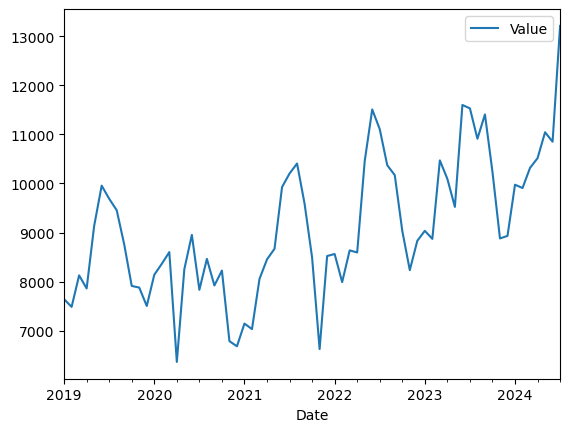

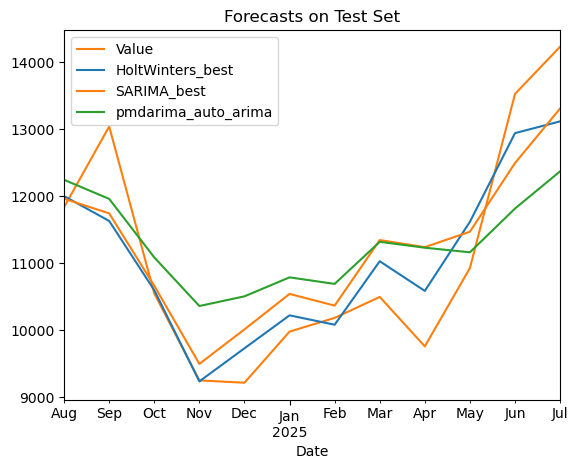

{'train':                Value
 Date                
 2019-01-01   7643.41
 2019-02-01   7487.43
 2019-03-01   8129.01
 2019-04-01   7862.02
 2019-05-01   9135.89
 ...              ...
 2024-03-01  10317.57
 2024-04-01  10515.29
 2024-05-01  11042.85
 2024-06-01  10850.59
 2024-07-01  13208.22
 
 [67 rows x 1 columns],
 'test':                Value
 Date                
 2024-08-01  11830.49
 2024-09-01  13033.53
 2024-10-01  10543.53
 2024-11-01   9245.91
 2024-12-01   9211.41
 2025-01-01   9973.75
 2025-02-01  10178.31
 2025-03-01  10491.04
 2025-04-01   9753.51
 2025-05-01  10921.98
 2025-06-01  13519.46
 2025-07-01  14223.45,
 'forecasts': {'HoltWinters_best': 2024-08-01    11995.252427
  2024-09-01    11624.363942
  2024-10-01    10590.923092
  2024-11-01     9231.157098
  2024-12-01     9725.026899
  2025-01-01    10216.352434
  2025-02-01    10076.563886
  2025-03-01    11023.558690
  2025-04-01    10581.027032
  2025-05-01    11612.156742
  2025-06-01    12934.487553
  2025-07-

In [52]:
run_full_pipeline(df_final)